In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [14]:
df = pd.read_csv('bodyPerformance.csv')

# Hacemos binario equilibrado

df_A = df[df["class"] == "A"]
df_B = df[df["class"] == "B"]
df_C = df[df["class"] == "C"]
df_D = df[df["class"] == "D"]

n_A = len(df_A)
n_por_clase = n_A // 3

df_B_sample = df_B.sample(n=n_por_clase, random_state=42)
df_C_sample = df_C.sample(n=n_por_clase, random_state=42)
df_D_sample = df_D.sample(n=n_por_clase, random_state=42)

df_0 = pd.concat([df_B_sample, df_C_sample, df_D_sample])

df_A["target"] = 1
df_0["target"] = 0

df_final = pd.concat([df_A, df_0]).sample(frac=1, random_state=42).reset_index(drop=True)

# Ingeniería de variables
df_final['bmi'] = df_final['weight_kg'] / ((df_final['height_cm'] / 100) ** 2)
df_final['relative_grip'] = df_final['gripForce'] / df_final['weight_kg']

df_final['gender'] = df_final['gender'].map({'M': 1, 'F': 0})

# Dividimos entre datos y objetivo teniendo en cuenta el género
y = df_final[df_final['gender'] == 0]['target']
X = df_final[df_final['gender'] == 0].drop(columns=['class', 'target'], axis=1)

C:\Users\miguelmr\AppData\Local\Temp\ipykernel_18568\2100074813.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_A["target"] = 1


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Estandarizamos los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creamos la arquitectura de la red MLP
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid') 
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks para mejorar rendimiento de entrenamiento
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=0)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

# Entrenamos
print("Entrenando MLP Binario...")
history = model.fit(
    X_train_scaled, y_train, 
    epochs=100, 
    batch_size=32, 
    validation_split=0.1, 
    callbacks=[reduce_lr, early_stop],
    verbose=1
)

Entrenando MLP Binario...
Epoch 1/100


c:\Users\miguelmr\anaconda3\envs\general\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7640 - loss: 0.5204 - val_accuracy: 0.8451 - val_loss: 0.4763 - learning_rate: 0.0010
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8205 - loss: 0.4130 - val_accuracy: 0.8592 - val_loss: 0.3992 - learning_rate: 0.0010
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8315 - loss: 0.3899 - val_accuracy: 0.8732 - val_loss: 0.3706 - learning_rate: 0.0010
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8378 - loss: 0.3737 - val_accuracy: 0.9155 - val_loss: 0.3065 - learning_rate: 0.0010
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8456 - loss: 0.3521 - val_accuracy: 0.8967 - val_loss: 0.2712 - learning_rate: 0.0010
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8509 - loss: 0.3381 - val_accuracy: 0.9108 - val_loss: 0.2527 - learning_rate: 0.0010
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8556 - loss: 0.3379 - val_accuracy: 0.910

In [16]:
# Comprobamos resultados
# Establecemos si la probabilidad es mayor a 0.5, es Élite
y_pred_mlp = (model.predict(X_test_scaled) > 0.5).astype(int) 

final_acc_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"\nMejor precisión de MLP: {final_acc_mlp:.4f}")

print("\nDatos del aprendizaje")
print(classification_report(y_test, y_pred_mlp, target_names=['No Élite', 'Élite']))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Mejor precisión de MLP: 0.8908

Datos del aprendizaje
              precision    recall  f1-score   support

    No Élite       0.92      0.84      0.88       249
       Élite       0.87      0.94      0.90       282

    accuracy                           0.89       531
   macro avg       0.90      0.89      0.89       531
weighted avg       0.89      0.89      0.89       531



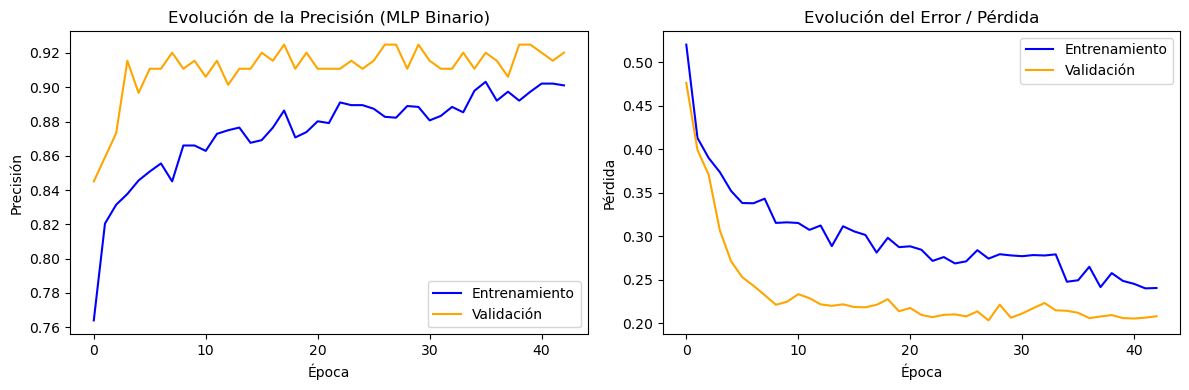

In [17]:
plt.figure(figsize=(12, 4))

# Gráfica Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento', color='blue')
plt.plot(history.history['val_accuracy'], label='Validación', color='orange')
plt.title('Evolución de la Precisión (MLP Binario)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Gráfica Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento', color='blue')
plt.plot(history.history['val_loss'], label='Validación', color='orange')
plt.title('Evolución del Error / Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

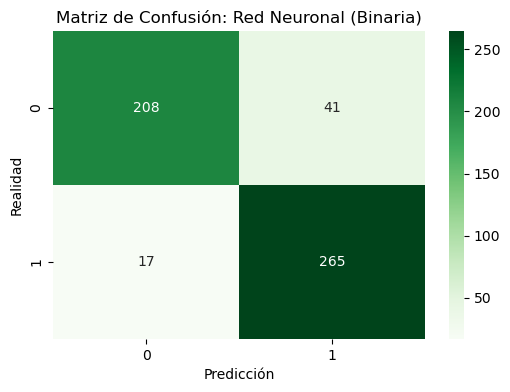

In [18]:
# Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='Greens')
plt.title("Matriz de Confusión: Red Neuronal (Binaria)")
plt.xlabel("Predicción")
plt.ylabel("Realidad")
plt.show()